# Task 1: Implement a function that detects lines in an image based on Hough-voting.
**Do not use** the built-in OpenCV function cv2.HoughLines() (you may use it for comparison only). You are free to use the provided image (input_ex3.jpg) or your own photos containing visible straight lines. All utility functions mentioned below can be found in Moodle.

## a\) Read the input image and convert it to a grayscale image with a value range [0, 1]. Plot the result image.

### Imports and Image Preperation

In [263]:
import os
import numpy as np
import matplotlib.pyplot as plt
from fontTools.merge import cmap
from scipy import signal

from utils.imadjust_utils import imadjust
from utils.hough_utils import houghlines, houghpeaks

In [264]:
# Load image
I = plt.imread(os.path.join("..", "input_ex3.jpg"))

# Convert to grayscale if RGB
if I.ndim == 3:
    I = I.mean(axis=2)

# Convert to double precision and normalize
I = I.astype(np.float64)
I = (I - I.min()) / (I.max() - I.min())

### Visualize Input Image

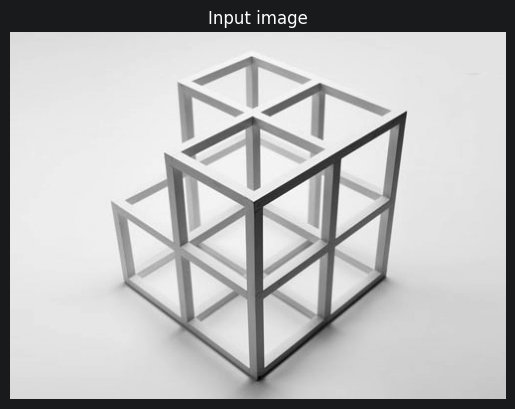

In [265]:
plt.imshow(I, cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

## b\) Apply a GoG filter (from assignment 2) to derive gradient images in x- and y-direction and compute the gradient magnitude.

In [266]:
def gog_kernels(sigma, size):
    k = size // 2
    x, y = np.meshgrid(
        np.arange(-k, k + 1),
        np.arange(-k, k + 1)
    )
    G = (1 / (2 * np.pi * sigma**2)) * np.exp(-(x**2 + y**2) / (2 * sigma**2))
    Gx = -x / sigma**2 * G
    Gy = -y / sigma**2 * G
    return Gx, Gy

In [267]:
sigma = 0.8
ksize = 7

Gx, Gy = gog_kernels(sigma, ksize)

Ix = signal.convolve2d(I, Gx, mode="valid")
Iy = signal.convolve2d(I, Gy, mode="valid")

Gmag = np.sqrt(Ix**2 + Iy**2)

## c\) Threshold gradient magnitude

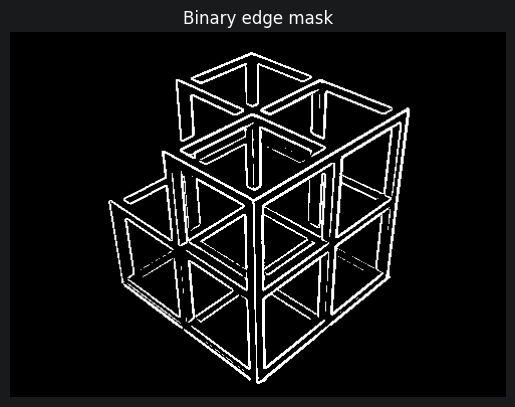

In [268]:
threshold = 0.2 * np.max(Gmag)
edges = Gmag > threshold

plt.imshow(edges, cmap="gray")
plt.title("Binary edge mask")
plt.axis("off")
plt.show()

## d\) Hough line detection

In [269]:
def hough_lines(edges, Ix, Iy, num_theta=360):
    rows, cols = edges.shape

    # Theta range (in degrees)
    theta = np.linspace(-90, 89, num_theta)
    # Convert to radians for trigonometric functions
    theta_rad = np.radians(theta)
    cos_t = np.cos(theta_rad)
    sin_t = np.sin(theta_rad)

    # Rho range
    diag_len = int(np.ceil(np.sqrt(rows**2 + cols**2)))
    rho = np.linspace(-diag_len, diag_len, 2 * diag_len + 1)

    H = np.zeros((len(rho), len(theta)), dtype=np.float64)

    ys, xs = np.nonzero(edges)

    # Gradient direction (in radians, range [-π, π])
    grad_theta = np.arctan2(Iy[ys, xs], Ix[ys, xs])

    for i in range(len(xs)):
        x = xs[i]
        y = ys[i]

        # Convert gradient angle from radians to degrees
        theta_line = np.degrees(grad_theta[i])
        theta_line = ((theta_line + 90) % 180) - 90

        # Find closest theta bin
        t_idx = np.argmin(np.abs(theta - theta_line))

        r = x * cos_t[t_idx] + y * sin_t[t_idx]
        r_idx = np.argmin(np.abs(rho - r))

        H[r_idx, t_idx] += 1

    return H, theta, rho

In [270]:
H, theta, rho = hough_lines(edges, Ix, Iy)

## e\) Plot Hough voting array

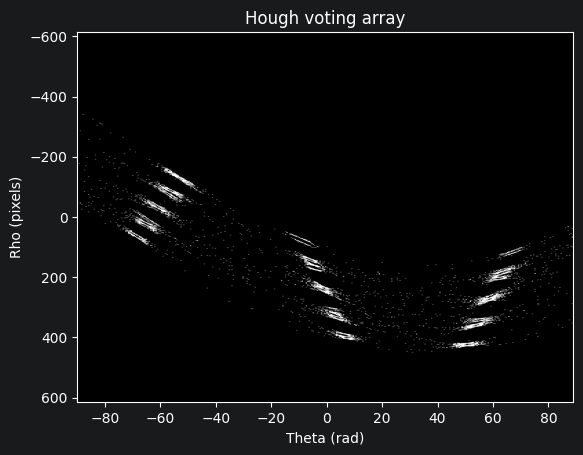

In [271]:
H_norm = H / H.max()  
H_adj = imadjust(H_norm)

plt.imshow(
    H_adj,
    cmap="gray",
    extent=(theta[0], theta[-1], rho[-1], rho[0]),
    aspect="auto"
)
plt.xlabel("Theta (rad)")
plt.ylabel("Rho (pixels)")
plt.title("Hough voting array")
plt.show()

## f\) Find local maxima (Hough peaks)

In [272]:
num_peaks = 20
peaks = houghpeaks(H, num_peaks, threshold=0.15)

## g\) Plot peaks on Hough Space

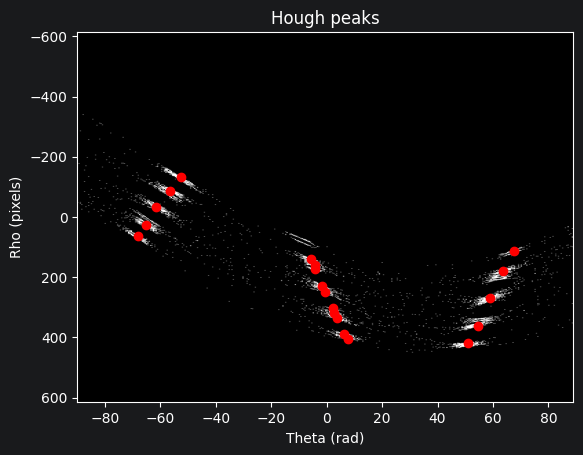

In [273]:
plt.imshow(
    H_adj,
    cmap="gray",
    extent=(theta[0], theta[-1], rho[-1], rho[0]),
    aspect="auto"
)
plt.scatter(theta[peaks[:,1]], rho[peaks[:,0]], c="r")
plt.xlabel("Theta (rad)")
plt.ylabel("Rho (pixels)")
plt.title("Hough peaks")
plt.show()

## h\) Extract line segments

In [274]:
lines = houghlines(edges, theta, rho, peaks)

## i\) Plot detected lines on original image

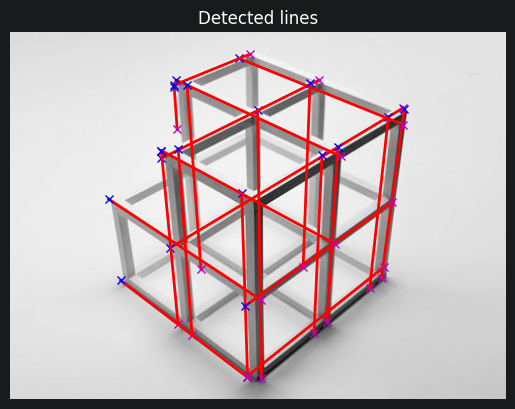

In [284]:
plt.imshow(I, cmap="gray")
plt.axis("off")

for line in lines:
    p1 = line["point1"]
    p2 = line["point2"]
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], "r", linewidth=2)

    plt.plot(p1[0], p1[1], 'bx')
    plt.plot(p2[0], p2[1], 'mx')

plt.title("Detected lines")
plt.show()